=== VERIFICACIÓN DE DIMENSIONES ===
Forma de la matriz de ventanas: (19, 256) (ventanas, canales, muestras)
Forma de la matriz de características X: (19, 12) (ventanas, rasgos)
¿Cantidad de rasgos esperados (12)?: SÍ



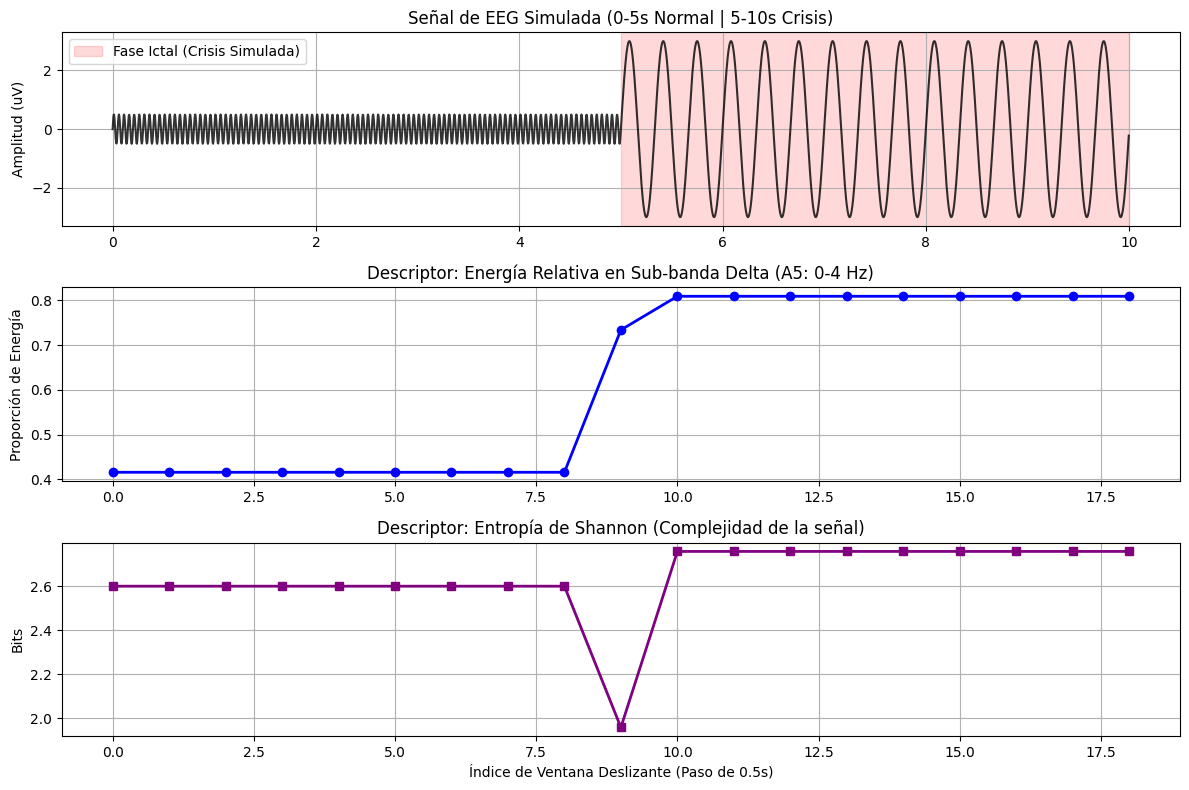

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Permitir que el notebook importe desde la carpeta 'src'
sys.path.append(os.path.abspath('../'))
from src.preprocessing.windowing import segment_eeg_signals
from src.features.extraction import extract_features_pipeline

# =====================================================================
# 1. SIMULACIÓN DE SEÑAL EEG: FONDO (NORMAL) VS. CRISIS (ICTAL)
# =====================================================================
fs = 256
duracion_total = 10  # 10 segundos totales
t = np.linspace(0, duracion_total, duracion_total * fs, endpoint=False)
num_canales = 1  # Probamos con 1 canal para visualizarlo fácil

# Primeros 5 segundos: EEG de fondo normal (alta frecuencia/baja amplitud - ritmos Beta)
fondo_normal = 0.5 * np.sin(2 * np.pi * 20 * t[:5*fs]) 

# Últimos 5 segundos: Simulación de crisis (baja frecuencia/alta amplitud - ritmo Delta/Theta ictal)
crisis_ictal = 3.0 * np.sin(2 * np.pi * 3 * t[5*fs:]) 

# Concatenamos para armar la señal continua del canal
eeg_crudo = np.concatenate([fondo_normal, crisis_ictal])
# Le damos forma de matriz (canales, muestras)
eeg_matriz = np.expand_dims(eeg_crudo, axis=0)

# =====================================================================
# 2. PROCESAMIENTO: VENTANEO Y EXTRACCIÓN DE CARACTERÍSTICAS (DWT db4)
# =====================================================================
# Segmentamos en ventanas de 1s con 50% de solapamiento (da 19 ventanas) [cite: 54, 55]
ventanas = segment_eeg_signals(eeg_matriz, fs=fs, window_duration=1.0, overlap_percentage=0.5)

# Extraemos el vector de rasgos por ventana [cite: 109, 115]
X_features = extract_features_pipeline(ventanas)

# =====================================================================
# 3. VERIFICACIÓN DE DIMENSIONES Y ANÁLISIS DE RESULTADOS
# =====================================================================
print("=== VERIFICACIÓN DE DIMENSIONES ===")
print(f"Forma de la matriz de ventanas: {ventanas.shape} (ventanas, canales, muestras)")
print(f"Forma de la matriz de características X: {X_features.shape} (ventanas, rasgos)")

# Recordando el mapeo: 1 canal * 4 sub-bandas (A5, D5, D4, D3) * 3 descriptores = 12 columnas [cite: 109, 115]
columnas_esperadas = 12
print(f"¿Cantidad de rasgos esperados ({columnas_esperadas})?: {'SÍ' if X_features.shape[1] == columnas_esperadas else 'NO'}\n")

# =====================================================================
# 4. GRAFICACIÓN: COMPORTAMIENTO DE LA ENERGÍA RELATIVA EN DELTA (A5)
# =====================================================================
# Según el orden en extraction.py, para el canal 0, los primeros 3 rasgos son de A5:
# índice 0: Energía Relativa A5 | índice 1: Varianza A5 | índice 2: Entropía A5 [cite: 109, 115]
energia_relativa_A5 = X_features[:, 0]
entropia_A5 = X_features[:, 2]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

# Gráfico 1: La señal de EEG continua
ax1.plot(t, eeg_crudo, color='black', alpha=0.8)
ax1.axvspan(5, 10, color='red', alpha=0.15, label='Fase Ictal (Crisis Simulada)')
ax1.set_title("Señal de EEG Simulada (0-5s Normal | 5-10s Crisis)")
ax1.set_ylabel("Amplitud (uV)")
ax1.legend(loc='upper left')
ax1.grid(True)

# Gráfico 2: Evolución de la Energía Relativa en Delta (A5)
# El eje X representa el índice de la ventana temporal
ax2.plot(range(len(energia_relativa_A5)), energia_relativa_A5, marker='o', color='blue', linewidth=2)
ax2.set_title("Descriptor: Energía Relativa en Sub-banda Delta (A5: 0-4 Hz)") 
ax2.set_ylabel("Proporción de Energía")
ax2.grid(True)

# Gráfico 3: Evolución de la Entropía de Shannon en Delta (A5)
ax3.plot(range(len(entropia_A5)), entropia_A5, marker='s', color='purple', linewidth=2)
ax3.set_title("Descriptor: Entropía de Shannon (Complejidad de la señal)") 
ax3.set_ylabel("Bits")
ax3.set_xlabel("Índice de Ventana Deslizante (Paso de 0.5s)")
ax3.grid(True)

plt.tight_layout()
plt.show()